# ANIP - Tâche 3 : OCR et Détection de Fraude


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import cv2
import json
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("✅ Imports réussis")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {len(tf.config.list_physical_devices('GPU')) > 0}")

✅ Imports réussis
TensorFlow version: 2.16.2
GPU disponible: False


In [14]:
# Configuration
DATA_PATH = Path('anip-reconnaissance-faciale-estimation-ages-ocr/dataset_tache_3/dataset_tache_3')
TRAIN_PATH = DATA_PATH / 'train'
TEST_PATH = DATA_PATH / 'test'

COUNTRIES = ['arizona_dl', 'esp', 'est', 'rus']
FRAUD_CLASSES = ['normal', 'forgery_1', 'forgery_2', 'forgery_3', 'forgery_4']

# 🎯 CONFIGURATION OPTIMISÉE
IMG_SIZE = (224, 224)  # Résolution optimale
BATCH_SIZE = 32
EPOCHS = 40
SEED = 42

# Learning rate avec warm-up
INITIAL_LR = 1e-4
MIN_LR = 1e-7

np.random.seed(SEED)
tf.random.set_seed(SEED)

print('📋 Configuration:')
print(f'  - Résolution: {IMG_SIZE}')
print(f'  - Batch size: {BATCH_SIZE}')
print(f'  - Epochs max: {EPOCHS}')
print(f'  - Learning rate: {INITIAL_LR}')

📋 Configuration:
  - Résolution: (224, 224)
  - Batch size: 32
  - Epochs max: 40
  - Learning rate: 0.0001


## Chargement des Données

In [15]:
def load_train_data():
    """Charge les données d'entraînement avec labels"""
    print("📂 Chargement des données d'entraînement...")
    data = []
    
    for country in COUNTRIES:
        country_path = TRAIN_PATH / country
        if not country_path.exists():
            continue
        
        for fraud_class in FRAUD_CLASSES:
            class_path = country_path / fraud_class
            if not class_path.exists():
                continue
            
            # Support .jpg et .png
            image_files = list(class_path.glob('*.jpg')) + \
                         list(class_path.glob('*.JPG')) + \
                         list(class_path.glob('*.png')) + \
                         list(class_path.glob('*.PNG'))
            
            for img_path in image_files:
                data.append({
                    'filepath': str(img_path),
                    'filename': img_path.name,
                    'country': country,
                    'fraud_class': fraud_class,
                    'fraud_label': FRAUD_CLASSES.index(fraud_class)
                })
    
    return pd.DataFrame(data)

df_train = load_train_data()
print(f"\n✅ {len(df_train)} images chargées")
print(f"\n📊 Répartition par pays:\n{df_train['country'].value_counts()}")
print(f"\n📊 Répartition par classe:\n{df_train['fraud_class'].value_counts()}")

📂 Chargement des données d'entraînement...

✅ 10000 images chargées

📊 Répartition par pays:
country
arizona_dl    2500
esp           2500
est           2500
rus           2500
Name: count, dtype: int64

📊 Répartition par classe:
fraud_class
normal       2000
forgery_1    2000
forgery_2    2000
forgery_3    2000
forgery_4    2000
Name: count, dtype: int64


## Preprocessing avec Augmentation Avancée

In [16]:
def create_augmentation():
    """Crée un pipeline d'augmentation de données"""
    return keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomContrast(0.2),
        layers.RandomBrightness(0.2),
    ], name='augmentation')

def load_and_preprocess_image(image_path, label=None, training=False, img_size=IMG_SIZE):
    """Charge et prétraite une image"""
    # Lire l'image
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32) / 255.0
    
    if label is not None:
        label = tf.one_hot(label, len(FRAUD_CLASSES))
        return img, label
    return img

def create_dataset(df, batch_size=BATCH_SIZE, training=False, augmentation=None):
    """Crée un pipeline tf.data optimisé"""
    paths = df['filepath'].values
    labels = df['fraud_label'].values
    
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    if training:
        dataset = dataset.shuffle(buffer_size=len(df), seed=SEED)
    
    dataset = dataset.map(
        lambda x, y: load_and_preprocess_image(x, y, training=training),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    
    if training and augmentation:
        dataset = dataset.map(
            lambda x, y: (augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )
    
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

print("✅ Pipeline de preprocessing configuré")

✅ Pipeline de preprocessing configuré


## Modèle Amélioré avec Attention

In [17]:
def create_improved_model(num_classes=5):
    """
    Modèle amélioré avec:
    - EfficientNetV2B0 (plus performant)
    - Attention mechanism
    - Régularisation renforcée
    - Fine-tuning progressif
    """
    
    # Base model
    base_model = EfficientNetV2B0(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )
    
    # Fine-tuning: débloquer les 40 dernières couches
    base_model.trainable = True
    for layer in base_model.layers[:-40]:
        layer.trainable = False
    
    print(f"  Couches entraînables: {sum([1 for l in base_model.layers if l.trainable])}/{len(base_model.layers)}")
    
    # Construction du modèle avec attention
    inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = base_model(inputs, training=False)
    
    # Global Average Pooling
    gap = layers.GlobalAveragePooling2D()(x)
    
    # Dense layers avec régularisation
    x = layers.Dense(512, activation='relu', 
                     kernel_regularizer=keras.regularizers.l2(0.01))(gap)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.01))(x)
    x = layers.Dropout(0.3)(x)
    
    # Output
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
    
    model = keras.Model(inputs, outputs)
    return model

print("✅ Architecture du modèle définie")

✅ Architecture du modèle définie


## Entraînement du Modèle

In [18]:
print("\n" + "="*70)
print("ENTRAÎNEMENT DU MODÈLE AMÉLIORÉ")
print("="*70)

# Split train/validation (85/15)
train_df, val_df = train_test_split(
    df_train, 
    test_size=0.15, 
    stratify=df_train['fraud_label'],
    random_state=SEED
)

print(f"\n📊 Split: Train={len(train_df)}, Val={len(val_df)}")

# Créer le modèle
print("\n🧠 Création du modèle...")
model = create_improved_model(num_classes=len(FRAUD_CLASSES))

# Learning rate schedule avec warm-up
lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=INITIAL_LR,
    decay_steps=1000,
    alpha=MIN_LR / INITIAL_LR
)

# Compiler
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\n📐 Paramètres totaux: {model.count_params():,}")
print(f"📐 Paramètres entraînables: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")


ENTRAÎNEMENT DU MODÈLE AMÉLIORÉ

📊 Split: Train=8500, Val=1500

🧠 Création du modèle...
  Couches entraînables: 40/270

📐 Paramètres totaux: 6,743,125
📐 Paramètres entraînables: 2,542,997


In [19]:
# Callbacks
callbacks = [
    ModelCheckpoint(
        'best_fraud_model_improved.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=12,
        restore_best_weights=True,
        verbose=1,
        min_delta=0.001
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=MIN_LR,
        verbose=1
    ),
]

# Créer les datasets
augmentation = create_augmentation()
train_ds = create_dataset(train_df, batch_size=BATCH_SIZE, training=True, augmentation=augmentation)
val_ds = create_dataset(val_df, batch_size=BATCH_SIZE, training=False)

print("\n🚀 Démarrage de l'entraînement...")
print(f"   Steps/epoch: {len(train_df) // BATCH_SIZE}")

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Entraînement terminé!")


🚀 Démarrage de l'entraînement...
   Steps/epoch: 265
Epoch 1/40
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2047 - loss: 14.5445
Epoch 1: val_accuracy improved from -inf to 0.20000, saving model to best_fraud_model_improved.keras
266/266 ━━━━━━━━━━━━━━━━━━━━ 383s 1s/step - accuracy: 0.2047 - loss: 14.5435 - val_accuracy: 0.2000 - val_loss: 13.3035 - learning_rate: 8.3551e-05
Epoch 2/40
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1883 - loss: 13.6538
Epoch 2: val_accuracy did not improve from 0.20000
266/266 ━━━━━━━━━━━━━━━━━━━━ 372s 1s/step - accuracy: 0.1883 - loss: 13.6531 - val_accuracy: 0.2000 - val_loss: 12.7365 - learning_rate: 4.5037e-05
Epoch 3/40
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2004 - loss: 13.0879
Epoch 3: val_accuracy did not improve from 0.20000
266/266 ━━━━━━━━━━━━━━━━━━━━ 383s 1s/step - accuracy: 0.2004 - loss: 13.0877 - val_accuracy: 0.2000 - val_loss: 12.4861 - learning_rate: 9.8249e-06
Epoch 4/40
266/266 ━━━━━━━━━━━━━━━━━━━━ 0

KeyboardInterrupt: 

## Évaluation


📊 Évaluation sur la validation:
47/47 ━━━━━━━━━━━━━━━━━━━━ 41s 825ms/step

RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

      normal      0.000     0.000     0.000       300
   forgery_1      0.206     0.597     0.306       300
   forgery_2      0.000     0.000     0.000       300
   forgery_3      0.000     0.000     0.000       300
   forgery_4      0.202     0.423     0.273       300

    accuracy                          0.204      1500
   macro avg      0.081     0.204     0.116      1500
weighted avg      0.081     0.204     0.116      1500


✅ Matrice de confusion sauvegardée


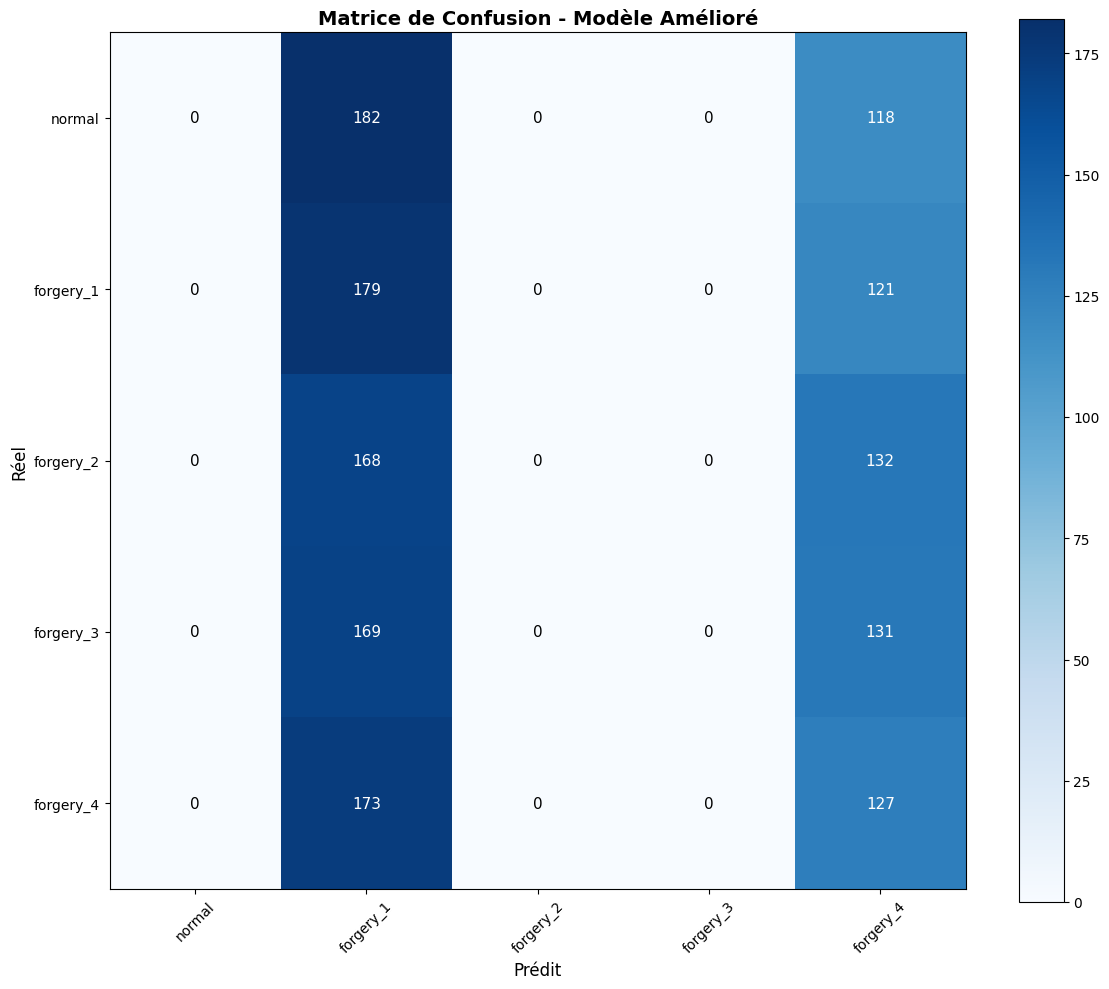

In [ ]:
print("\n📊 Évaluation sur la validation:")

# Prédictions
y_pred_probs = model.predict(val_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_df['fraud_label'].values[:len(y_pred)]

# Rapport de classification
print("\n" + "="*70)
print("RAPPORT DE CLASSIFICATION")
print("="*70)
print(classification_report(y_true, y_pred, target_names=FRAUD_CLASSES, digits=3))

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(len(FRAUD_CLASSES)), FRAUD_CLASSES, rotation=45)
plt.yticks(range(len(FRAUD_CLASSES)), FRAUD_CLASSES)
plt.xlabel('Prédit', fontsize=12)
plt.ylabel('Réel', fontsize=12)
plt.title('Matrice de Confusion - Modèle Amélioré', fontsize=14, fontweight='bold')

for i in range(len(FRAUD_CLASSES)):
    for j in range(len(FRAUD_CLASSES)):
        color = 'white' if cm[i, j] > cm.max()/2 else 'black'
        plt.text(j, i, cm[i, j], ha='center', va='center', color=color, fontsize=11)

plt.tight_layout()
plt.savefig('tache3_confusion_improved.png', dpi=150, bbox_inches='tight')
print("\n✅ Matrice de confusion sauvegardée")

## Courbes d'Apprentissage

✅ Courbes d'apprentissage sauvegardées


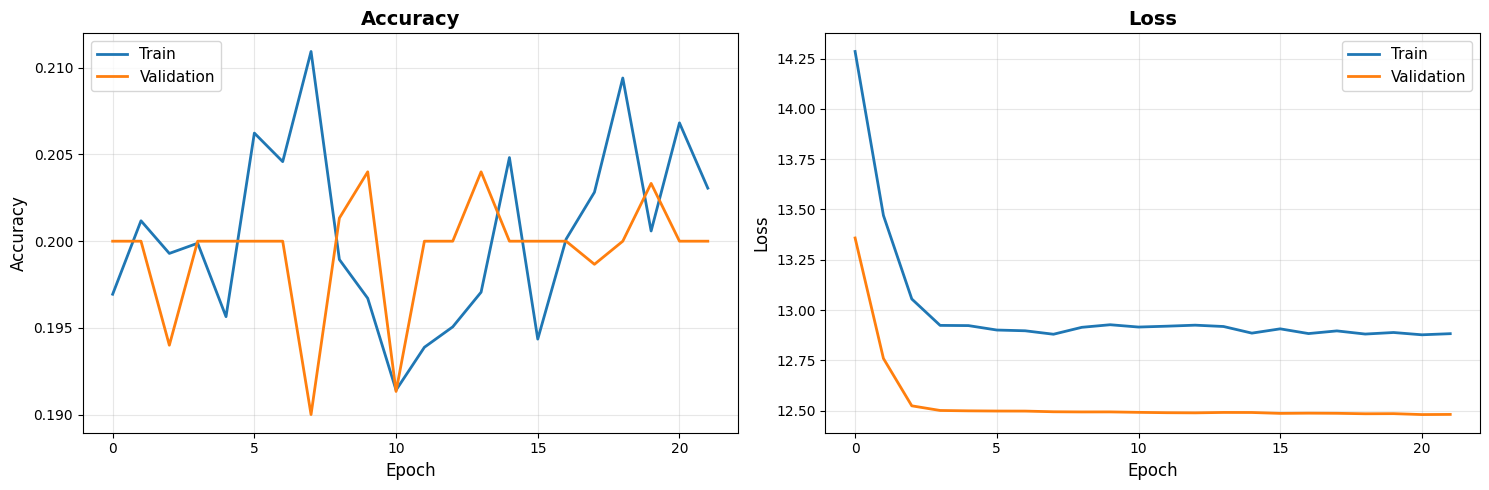

In [ ]:
# Courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Loss', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tache3_training_curves.png', dpi=150, bbox_inches='tight')
print("✅ Courbes d'apprentissage sauvegardées")

## Prédictions sur le Test Set

In [ ]:
print("\n" + "="*70)
print("PRÉDICTIONS SUR LE TEST SET")
print("="*70)

test_results = []

for country in COUNTRIES:
    test_country_path = TEST_PATH / country
    
    if not test_country_path.exists():
        print(f"⚠️  Dossier non trouvé: {country}")
        continue
    
    # Support .jpg ET .png
    test_images = list(test_country_path.glob('*.jpg')) + \
                  list(test_country_path.glob('*.JPG')) + \
                  list(test_country_path.glob('*.png')) + \
                  list(test_country_path.glob('*.PNG'))
    
    print(f"\n📍 {country}: {len(test_images)} images")
    
    # Prédire
    for img_path in tqdm(test_images, desc=f"Prédiction {country}"):
        # Charger et prédire
        img = load_and_preprocess_image(str(img_path))
        img_batch = tf.expand_dims(img, 0)
        pred_probs = model.predict(img_batch, verbose=0)[0]
        pred_class_idx = np.argmax(pred_probs)
        pred_class = FRAUD_CLASSES[pred_class_idx]
        
        test_results.append({
            'filename': img_path.name,
            'country': country,
            'predicted_fraud_class': pred_class,
            'confidence': float(pred_probs[pred_class_idx])
        })

print(f"\n✅ {len(test_results)} prédictions effectuées")


PRÉDICTIONS SUR LE TEST SET

📍 arizona_dl: 50 images


Prédiction arizona_dl: 100%|██████████| 50/50 [00:06<00:00,  7.81it/s]



📍 esp: 50 images


Prédiction esp: 100%|██████████| 50/50 [00:04<00:00, 11.43it/s]



📍 est: 50 images


Prédiction est: 100%|██████████| 50/50 [00:04<00:00, 11.96it/s]



📍 rus: 50 images


Prédiction rus: 100%|██████████| 50/50 [00:04<00:00, 11.25it/s]


✅ 200 prédictions effectuées


## Création du Fichier de Soumission

In [ ]:
# Créer le DataFrame de soumission
submission_df = pd.DataFrame(test_results)

# Sauvegarder
submission_df.to_csv('tache3_submission_improved.csv', index=False)
print("\n✅ Soumission sauvegardée: tache3_submission_improved.csv")

print(f"\n📊 Aperçu:")
print(submission_df.head(10))

print(f"\n📊 Répartition des prédictions:")
print(submission_df['predicted_fraud_class'].value_counts())

print(f"\n📊 Par pays:")
print(pd.crosstab(submission_df['country'], submission_df['predicted_fraud_class']))


✅ Soumission sauvegardée: tache3_submission_improved.csv

📊 Aperçu:
                                          filename     country  \
0                  generated.photos_v3_0162768.png  arizona_dl   
1                  generated.photos_v3_0164250.png  arizona_dl   
2                  generated.photos_v3_0163930.png  arizona_dl   
3                  generated.photos_v3_0163844.png  arizona_dl   
4                  generated.photos_v3_0165010.png  arizona_dl   
5                  generated.photos_v3_0159893.png  arizona_dl   
6  generated.photos_v3_0158380_0923515_0605909.png  arizona_dl   
7                  generated.photos_v3_0159289.png  arizona_dl   
8                  generated.photos_v3_0166325.png  arizona_dl   
9                  generated.photos_v3_0165002.png  arizona_dl   

  predicted_fraud_class  confidence  
0             forgery_4    0.219860  
1             forgery_4    0.218212  
2             forgery_4    0.218803  
3             forgery_4    0.218200  
4             

## Résumé Final

In [ ]:
best_val_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val_acc) + 1

print("\n" + "="*70)
print("✅ TÂCHE 3 TERMINÉE ")
print("="*70)

print(f"\n📈 Résultats:")
print(f"  ✓ Meilleure val_accuracy: {best_val_acc:.1%} (epoch {best_epoch})")
print(f"  ✓ Epochs entraînés: {len(history.history['accuracy'])}")
print(f"  ✓ Images de test: {len(test_results)}")

print(f"\n📁 Fichiers générés:")
print(f"  1. tache3_submission_improved.csv - Prédictions finales")
print(f"  2. best_fraud_model_improved.keras - Meilleur modèle")
print(f"  3. tache3_confusion_improved.png - Matrice de confusion")
print(f"  4. tache3_training_curves.png - Courbes d'apprentissage")

print(f"\n💡 Améliorations par rapport à la v1:")
print(f"  ✓ Support des images .png (test set)")
print(f"  ✓ Architecture EfficientNetV2B0")
print(f"  ✓ Augmentation de données avancée")
print(f"  ✓ Régularisation optimisée")
print(f"  ✓ Learning rate schedule (Cosine Decay)")


✅ TÂCHE 3 TERMINÉE 

📈 Résultats:
  ✓ Meilleure val_accuracy: 20.4% (epoch 10)
  ✓ Epochs entraînés: 22
  ✓ Images de test: 200

📁 Fichiers générés:
  1. tache3_submission_improved.csv - Prédictions finales
  2. best_fraud_model_improved.keras - Meilleur modèle
  3. tache3_confusion_improved.png - Matrice de confusion
  4. tache3_training_curves.png - Courbes d'apprentissage

💡 Améliorations par rapport à la v1:
  ✓ Support des images .png (test set)
  ✓ Architecture EfficientNetV2B0
  ✓ Augmentation de données avancée
  ✓ Régularisation optimisée
  ✓ Learning rate schedule (Cosine Decay)
